# M3 — Experiment Readout: does emailing *cause* more visits?

M1/M2 gave us an **observation**: emailed customers visit ~6 pp more often. This
notebook turns that into a **statistical conclusion** with honest uncertainty, by asking
three questions in order:

1. **Can we trust the experiment?** (Sample Ratio Mismatch check)
2. **Is each lift real, or noise?** (two-proportion z-test + bootstrap, with confidence
   intervals, corrected for multiple testing)
3. **What could this experiment even have detected?** (power / minimum detectable effect)

For every test we state, in order: the **business question**, the **intuition**, the
**assumptions**, and then run it.

> Because Hillstrom is a randomised experiment, a difference in means here is already an
> unbiased *causal* effect. So this readout does double duty: it is both the A/B-test
> analysis and our first, cleanest answer to "what is the ATE?".

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from mdip.config import load_config
from mdip.data.load import load_hillstrom
from mdip.stats.experiment import run_readout
from mdip.stats import plots
from mdip.stats.power import detectable_effect, required_sample_size
from mdip.viz.style import set_style

set_style()
cfg = load_config()
df = load_hillstrom(cfg)
results = run_readout(df, seed=cfg.seed, alpha=cfg.stats.alpha)

## 1. Can we trust the experiment? — Sample Ratio Mismatch (chi-square)

**Business question:** did customers actually land in the arms in the intended
1/3 : 1/3 : 1/3 ratio? If not, randomisation/logging is broken and nothing downstream
is safe.

**Intuition:** we expect ~21,333 per arm. Chi-square asks whether the gap between
observed and expected counts is ordinary random wobble or too large to be chance.

**Assumptions:** independent observations; large expected counts (here ~21k, so the
approximation is excellent). Note the logic is inverted from a normal test — here a
**large p-value is the good result** (no evidence of mismatch).

In [2]:
srm = results["srm"]
print("observed:", srm["observed"])
print("expected:", srm["expected"])
print(f"chi2 = {srm['chi2_statistic']:.3f}, p = {srm['p_value']:.3f}")
print(srm["verdict"])

observed: [21307, 21387, 21306]
expected: [21333.3, 21333.3, 21333.3]
chi2 = 0.203, p = 0.904
No SRM: arm sizes are consistent with the intended split.


**Observation:** chi-square p = 0.90 — far above any alarm threshold.
**Conclusion:** the experiment is balanced; treated-vs-control comparisons are fair.

## 2. Is each lift real? — two-proportion z-test & bootstrap

**Business question:** is the treated-vs-control gap in each outcome beyond chance?

**Intuition:** a rate is the average of 0/1 outcomes; two groups differ a little even
when the true effect is zero. The z-test measures the gap in units of its standard error
— beyond ~2 SE, chance is an unconvincing explanation. For **spend** (99% zeros, heavy
tail) the Normal approximation is poor, so we use a **bootstrap** CI instead.

**Assumptions (z-test):** independent observations; enough successes/failures per group
for a Normal approximation (visit: thousands; conversion: ~120+ — fine). We use a
*pooled* SE for the test statistic and an *unpooled* SE for the CI.

**Assumptions (bootstrap):** the sample represents the population; observations
independent. No Normality needed.

In [3]:
tests = results["tests"].copy()
for c in ["treated_rate","control_rate","lift","ci_low","ci_high"]:
    tests[c] = tests[c].round(5)
tests[["arm","outcome","test","lift","ci_low","ci_high","p_value","p_adjusted","significant_bh"]]

,arm,outcome,test,lift,ci_low,ci_high,p_value,p_adjusted,significant_bh
0,Mens E-Mail,visit,two-proportion z,0.07659,0.06995,0.08323,5.685165e-112,0.00000,True
1,Mens E-Mail,conversion,two-proportion z,0.00681,0.00500,0.00861,1.523224e-13,0.00000,True
2,Mens E-Mail,spend,bootstrap diff-in-means,0.76983,0.48636,1.05833,1.320939e-07,0.00000,True
3,Womens E-Mail,visit,two-proportion z,0.04523,0.03889,0.05157,3.182403e-44,0.00000,True
4,Womens E-Mail,conversion,two-proportion z,0.00311,0.00150,0.00472,1.571051e-04,0.00019,True
5,Womens E-Mail,spend,bootstrap diff-in-means,0.42441,0.16211,0.68411,1.437295e-03,0.00144,True


### The headline chart — a forest plot

Dot = estimated lift, line = 95% CI, dashed line = "no effect". A CI clear of zero means
the effect is statistically distinguishable from nothing.

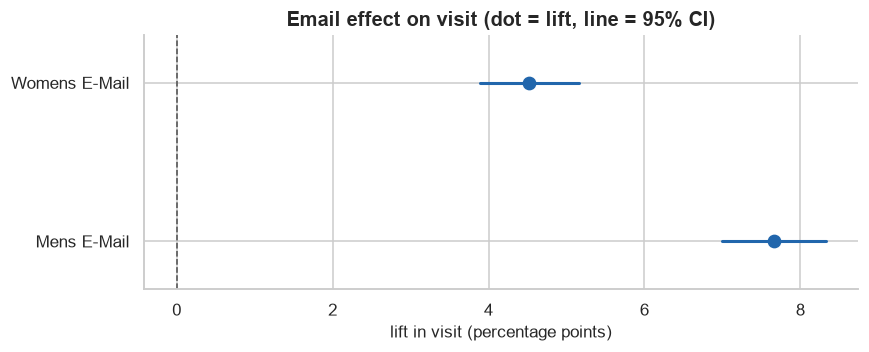

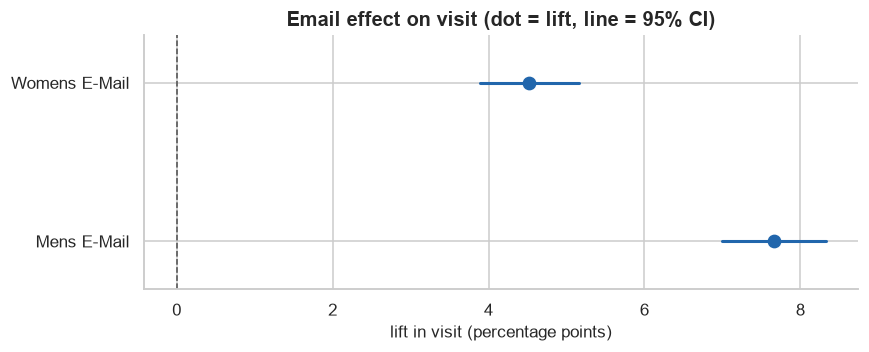

In [4]:
plots.plot_forest(tests, outcome="visit")

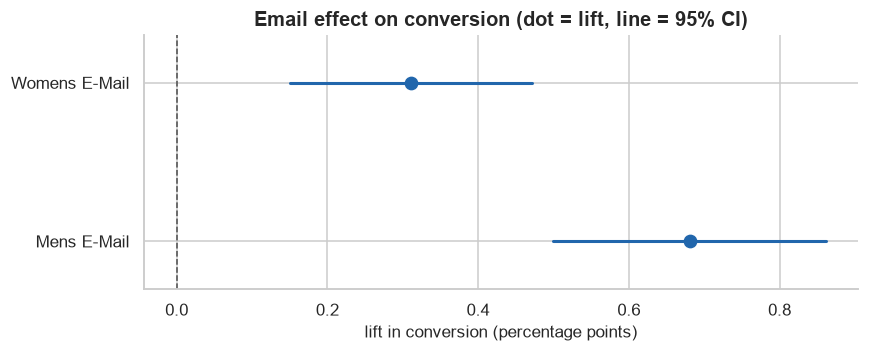

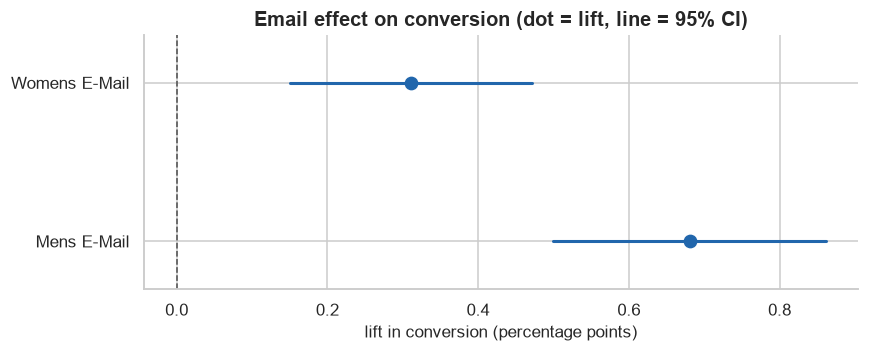

In [5]:
plots.plot_forest(tests, outcome="conversion")

**Observation:** every arm × outcome CI sits clearly above zero. Men's email lifts
visits by **+7.7 pp** [+7.0, +8.3] and women's by **+4.5 pp** [+3.9, +5.2]; both lift
conversion and spend significantly too.

**Conclusion:** emailing **causes** more visits and conversions (this is a clean RCT).
Men's email is roughly **1.7× as effective** as women's on visits — a strong hint that
*who* and *which creative* matters, which we pursue in M6. The effect is unambiguous, not
marginal.

## 2b. Why the multiple-testing correction?

**Business question:** we ran 6 tests (2 arms × 3 outcomes). Doesn't testing many things
inflate the chance of a false "significant"?

**Intuition:** at α = 0.05 each test has a 5% false-alarm rate; across 6 the chance of
*at least one* false positive exceeds 25%. Benjamini-Hochberg rescales the bar to control
the **false discovery rate** — the expected fraction of our "significant" calls that are
wrong.

**Assumptions:** tests independent or positively correlated (true here).

**Observation:** the `p_adjusted` column above is BH-corrected; every result stays
significant. **Conclusion:** our findings are robust to having looked at several outcomes
at once — these aren't multiple-comparisons artifacts.

## 3. What could this experiment have detected? — power / MDE

**Business question:** if email had only a tiny true effect, could we even have seen it?
And how large must a *future* test be to detect a target lift?

**Intuition:** power is the probability of catching a real effect of a given size; small
effects hide in noise unless the sample is big. The MDE is the smallest lift we could
reliably detect here.

**Assumptions:** Normal-approximation setup; α = 0.05, target power = 0.80.

In [6]:
control_visit = df.loc[df["treatment"] == 0, "visit"].mean()
n_per_arm = int(df["segment"].value_counts().min())
mde = detectable_effect(control_visit, n_per_arm)
n_needed = required_sample_size(control_visit, mde_absolute=cfg.stats.mde_lift)
print(f"control visit rate : {control_visit:.4f}")
print(f"customers per arm  : {n_per_arm:,}")
print(f"MDE at 80% power   : {mde*100:.3f} pp")
print(f"n/arm to detect a +1.0 pp lift : {n_needed:,}")

control visit rate : 0.1062
customers per arm  : 21,306
MDE at 80% power   : 0.851 pp
n/arm to detect a +1.0 pp lift : 15,504


**Observation:** with ~21,300 customers per arm we could detect a lift as small as
**~0.85 pp**; detecting a +1.0 pp lift needs ~15,500 per arm.

**Conclusion:** the study is **well-powered** for the effects we care about — the observed
+4.5–7.7 pp lifts are many times the MDE, so "significant" here also means "comfortably
detectable", not "barely scraped past the line". This is how I'd defend a result (or,
had it been null, correctly say "underpowered" rather than "no effect").

## Summary

| Question | Answer |
|---|---|
| Trustworthy experiment? | Yes — no SRM (p = 0.90) |
| Does email work? | Yes — visits +4.5 to +7.7 pp, all CIs clear of zero |
| Robust to multiple testing? | Yes — significant after Benjamini-Hochberg |
| Well-powered? | Yes — MDE ~0.85 pp, far below the observed effect |

**Cleanest ATE estimate so far (visit, any email vs control):** ~**+6.1 pp**. In M5 we'll
*re-derive* this with propensity-score matching on a deliberately biased copy of the data,
to prove the causal method works when randomisation is taken away.